# Bank Marketing ML Project
1. Data Loading
2. Dataset Overview (EDA)
3. Preprocessing
4. Modeling
5. Evaluation
6. Cross-validation & Tuning
7. Final Test Performance
8. Error Analysis & Threshold Tuning
9. Random Forest
10. Prediction (Optional)（XGBoost)
11. Model Explainability (SHAP)

## 1.1 Load Dataset (Local CSV)

In [1]:
# --------------------------------------------------
# 1. Data Loading (Local)
# 1. 本地数据读取
# --------------------------------------------------
# 1) imports
import pandas as pd
from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

# 2) file path (based on your folder structure)
# FILE_PATH = Path("data") / "bank+marketing" / "bank" / "bank-full.csv"

# 3) read csv (bank-full uses ';')
df_raw = pd.read_csv("/Users/mr.tian/Desktop/bank-full.csv", sep=";")

print("Shape:", df_raw.shape)
df_raw.head()

Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## 1.2 Define Features (X) and Target (y)

We split the raw table into:
- X: all feature columns
- y: the target label (`y` = yes/no)

This keeps the rest of the notebook consistent.

In [2]:
# --------------------------------------------------
# 1.2 Define X and y
# --------------------------------------------------

# Target (label)
y = df_raw["y"].copy()

# Features
X = df_raw.drop(columns=["y"]).copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("y values:", y.unique())

X shape: (45211, 16)
y shape: (45211,)
y values: ['no' 'yes']


## 2.1 Dataset Dimensions

Check:
- number of rows and features
- feature names (columns)

In [3]:
# --------------------------------------------------
# 2.1 Dataset Dimensions
# --------------------------------------------------
print("Rows:", X.shape[0])
print("Features:", X.shape[1])

# --------------------------------------------------
# Split features by type
# --------------------------------------------------
num_cols = X.select_dtypes(include=["number"]).columns.tolist()
non_num_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

print("\nNumerical features:")
print(num_cols)

print("\nNon-numerical features:")
print(non_num_cols)

print("\nCounts -> Numerical:", len(num_cols), "| Non-numerical:", len(non_num_cols))

Rows: 45211
Features: 16

Numerical features:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Non-numerical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Counts -> Numerical: 7 | Non-numerical: 9


## 2.2 Target Balance

Check the distribution of the target label `y`:
- counts (yes/no)
- percentage (class imbalance)

In [4]:
# --------------------------------------------------
# 2.2 Target Balance
# --------------------------------------------------
print("Target counts:")
print(y.value_counts())

print("\nTarget percentage:")
print((y.value_counts(normalize=True) * 100).round(2))

Target counts:
y
no     39922
yes     5289
Name: count, dtype: int64

Target percentage:
y
no     88.3
yes    11.7
Name: proportion, dtype: float64


### 2.2.1 Plot: Target Balance (Pie Chart)

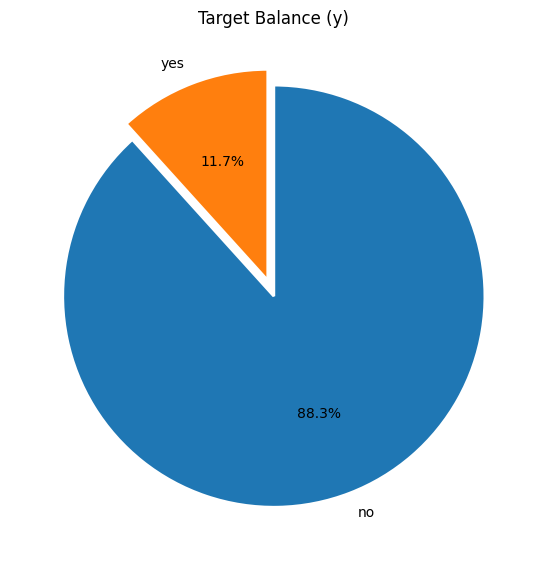

In [5]:
import matplotlib.pyplot as plt

# Prepare data
counts = y.value_counts()
labels = counts.index.tolist()

# Highlight the positive class (yes)
explode = [0.0] * len(labels)
if "yes" in labels:
    explode[labels.index("yes")] = 0.08

# High-contrast colors + white borders for readability
colors = ["tab:blue" if lab != "yes" else "tab:orange" for lab in labels]

plt.figure(figsize=(5.8, 5.8))
plt.pie(
    counts.values,
    labels=labels,
    autopct="%.1f%%",
    startangle=90,
    counterclock=False,
    explode=explode,
    colors=colors,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
plt.title("Target Balance (y)")
plt.tight_layout()
plt.show()

## 2.3 Missing Values (NaN vs Blank vs "unknown")

We report missingness in three ways:
- NaN missing (true nulls)
- blank / empty strings in categorical columns
- "unknown" category counts (often treated as missing in practice)

In [6]:
# A) True NaN missing
nan_missing = X.isnull().sum()
nan_missing = nan_missing[nan_missing > 0].sort_values(ascending=False)

# B) Blank / empty strings in non-numerical columns
blank_missing = {}
for c in non_num_cols:
    s = X[c].astype(str).str.strip()   # 去掉左右空格
    blank_missing[c] = (s == "").sum() # 统计空字符串

blank_missing = pd.Series(blank_missing).sort_values(ascending=False)
blank_missing = blank_missing[blank_missing > 0]

print("Blank-string missing (categorical):")
print(blank_missing if len(blank_missing) else "No blank-string missing.")

print("NaN-missing columns:")
print(nan_missing if len(nan_missing) else "No NaN missing.")

# C) 'unknown' counts in non-numerical columns
unknown_counts = {}
for c in non_num_cols:
    unknown_counts[c] = (X[c].astype(str).str.lower().str.strip() == "unknown").sum()

unknown_counts = pd.Series(unknown_counts).sort_values(ascending=False)
unknown_counts = unknown_counts[unknown_counts > 0]

print("'unknown' counts (categorical):")
print(unknown_counts if len(unknown_counts) else "No 'unknown' category found.")

Blank-string missing (categorical):
No blank-string missing.
NaN-missing columns:
No NaN missing.
'unknown' counts (categorical):
poutcome     36959
contact      13020
education     1857
job            288
dtype: int64


### 2.3.1 "unknown" as missing (Categorical)

In this dataset, missing information is mostly encoded as the category value `"unknown"`.
Below we report the count and percentage of `"unknown"` for each categorical feature.

In [7]:
# --------------------------------------------------
# 2.3.1 'unknown' missing summary (count + %)
# --------------------------------------------------
unknown_summary = pd.DataFrame({
    "unknown_count": unknown_counts,
    "unknown_pct": (unknown_counts / len(X) * 100).round(2)
}).sort_values("unknown_count", ascending=False)

print(unknown_summary)

           unknown_count  unknown_pct
poutcome           36959        81.75
contact            13020        28.80
education           1857         4.11
job                  288         0.64


### 2.3.2 Plot: "unknown" as missing (percentage)

Bar chart of the `"unknown"` percentage for each categorical feature.

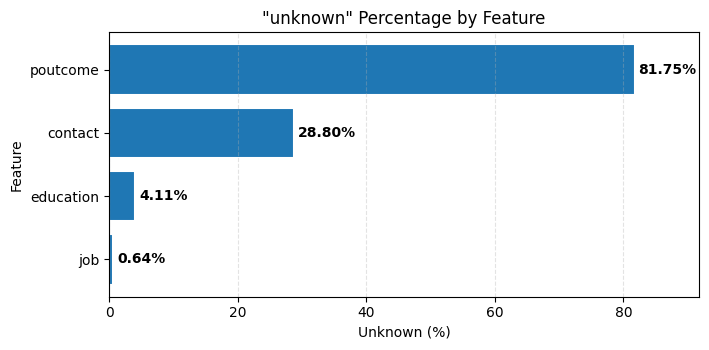

In [8]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Use the summary table you already printed
plot_df = unknown_summary.sort_values("unknown_pct", ascending=True)

fig, ax = plt.subplots(figsize=(7.2, 3.6))

# High-contrast bars
ax.barh(plot_df.index, plot_df["unknown_pct"], edgecolor="white", linewidth=1.5)
ax.set_title('"unknown" Percentage by Feature')
ax.set_xlabel("Unknown (%)")
ax.set_ylabel("Feature")

# Reduce grid density + use dashed, light grid (x-axis only)
ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
ax.grid(axis="x", linestyle="--", linewidth=0.8, alpha=0.35)
ax.grid(axis="y", visible=False)

# Add bold/darker labels at the end of bars
for i, (feat, v) in enumerate(zip(plot_df.index, plot_df["unknown_pct"].values)):
    ax.text(v + 0.6, i, f"{v:.2f}%", va="center", fontweight="bold")

# Add a little padding on the right so labels don't get cut off
ax.set_xlim(0, plot_df["unknown_pct"].max() + 10)

plt.tight_layout()
plt.show()

## 2.4 Quick Data Notes (EDA Takeaways)

- Target is imbalanced: yes 11.7%, no 88.3%.
- No NaN/blank missing values, but `"unknown"` is common in categorical features:
  poutcome (81.75%), contact (28.80%), education (4.11%), job (0.64%).
- Next: build a preprocessing pipeline (encode categorical, scale numeric) and decide how to handle `"unknown"`.

### Check: Does `contact = unknown` imply lower subscription rate?

We compare subscription rates across contact types (cellular / telephone / unknown).

In [9]:
# Subscription rate by contact type
contact_summary = (
    df_raw.groupby("contact")["y"]
    .apply(lambda s: (s.str.lower() == "yes").mean())
    .sort_values(ascending=False)
    .to_frame(name="subscribe_rate")
)

# Add counts for context
contact_counts = df_raw["contact"].value_counts().to_frame(name="count")
contact_summary = contact_counts.join(contact_summary)

# Convert to percentage
contact_summary["subscribe_rate_pct"] = (contact_summary["subscribe_rate"] * 100).round(2)

contact_summary

,count,subscribe_rate,subscribe_rate_pct
contact,,,
cellular,29285,0.149189,14.92
unknown,13020,0.040707,4.07
telephone,2906,0.134205,13.42


In [10]:
# Counts
ct = pd.crosstab(df_raw["contact"], df_raw["y"])
print(ct)

# Row percentages (each contact type's yes/no proportion)
ct_pct = pd.crosstab(df_raw["contact"], df_raw["y"], normalize="index") * 100
print("\nRow %:")
print(ct_pct.round(2))

y             no   yes
contact               
cellular   24916  4369
telephone   2516   390
unknown    12490   530

Row %:
y             no    yes
contact                
cellular   85.08  14.92
telephone  86.58  13.42
unknown    95.93   4.07


## 2.5 Quick Visual EDA

We add a few simple plots to summarize the dataset:
- Target balance (y)
- "unknown" as missing in categorical features
- A few key numeric feature distributions (optional)

## 3.1 Define Target and Feature Set

Create:
- `y_bin`: binary label (yes=1, no=0)
- `X_model`: features used for modeling (drop `duration` to avoid leakage)
- updated numeric vs categorical column lists

In [11]:
# --------------------------------------------------
# 3.1 Define modeling target and feature set
# --------------------------------------------------

# 1) Binary target: yes -> 1, no -> 0
y_bin = (y.astype(str).str.lower() == "yes").astype(int)

# 2) Drop potential leakage feature (call duration after the call ends)
X_model = X.drop(columns=["duration"], errors="ignore")

# 3) Recompute numeric / categorical columns for X_model
num_cols_model = X_model.select_dtypes(include=["number"]).columns.tolist()
cat_cols_model = X_model.select_dtypes(exclude=["number"]).columns.tolist()

print("y_bin distribution:")
print(y_bin.value_counts())

print("\nX_model shape:", X_model.shape)
print("Numeric cols:", len(num_cols_model))
print("Categorical cols:", len(cat_cols_model))

y_bin distribution:
y
0    39922
1     5289
Name: count, dtype: int64

X_model shape: (45211, 15)
Numeric cols: 6
Categorical cols: 9


## 3.2 Train/Test Split

Split the data into training and test sets.
- Use stratified split to keep the same class ratio in both sets.
- Keep the test set untouched until final evaluation.

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_bin,
    test_size=0.2,
    random_state=42,
    stratify=y_bin
)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("Train positive %:", round(y_train.mean() * 100, 2))
print("Test positive %:", round(y_test.mean() * 100, 2))

Train shape: (36168, 15) | Test shape: (9043, 15)
Train positive %: 11.7
Test positive %: 11.7


## 3.3 Preprocessing Pipeline

We build a single preprocessing pipeline:
- Numeric: impute (median) + scale (standardization)
- Categorical: impute (most frequent) + one-hot encode

We will reuse the same preprocessor for all models.

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Numeric preprocessing: median imputation + scaling
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Categorical preprocessing: most-frequent imputation + one-hot
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

# Combine
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols_model),
        ("cat", categorical_transformer, cat_cols_model),
    ]
)

print("Preprocessor ready.")

Preprocessor ready.


### Check One-Hot Output (Dimension + Feature Names)

We inspect the transformed feature space after preprocessing:
- total number of features after one-hot encoding
- the generated feature names

In [14]:
# Fit preprocessor on training data
preprocessor.fit(X_train, y_train)

# 1) How many features after preprocessing?
X_train_trans = preprocessor.transform(X_train)
print("After preprocessing shape (rows, features):", X_train_trans.shape)

# 2) What are the feature names?
feature_names = preprocessor.get_feature_names_out()
print("Total feature names:", len(feature_names))

# Show a preview (first 30)
print("\nFirst 30 feature names:")
print(feature_names[:30])

# Show a preview (last 30)
print("\nLast 30 feature names:")
print(feature_names[-30:])

# Optional: list ONLY one-hot generated features (categorical part)
cat_feature_names = [n for n in feature_names if n.startswith("cat__")]
print("\nTotal one-hot (categorical) features:", len(cat_feature_names))
print("Sample one-hot feature names:")
print(cat_feature_names[:30])

After preprocessing shape (rows, features): (36168, 50)
Total feature names: 50

First 30 feature names:
['num__age' 'num__balance' 'num__day' 'num__campaign' 'num__pdays'
 'num__previous' 'cat__job_admin.' 'cat__job_blue-collar'
 'cat__job_entrepreneur' 'cat__job_housemaid' 'cat__job_management'
 'cat__job_retired' 'cat__job_self-employed' 'cat__job_services'
 'cat__job_student' 'cat__job_technician' 'cat__job_unemployed'
 'cat__job_unknown' 'cat__marital_divorced' 'cat__marital_married'
 'cat__marital_single' 'cat__education_primary' 'cat__education_secondary'
 'cat__education_tertiary' 'cat__education_unknown' 'cat__default_no'
 'cat__default_yes' 'cat__housing_no' 'cat__housing_yes' 'cat__loan_no']

Last 30 feature names:
['cat__marital_single' 'cat__education_primary' 'cat__education_secondary'
 'cat__education_tertiary' 'cat__education_unknown' 'cat__default_no'
 'cat__default_yes' 'cat__housing_no' 'cat__housing_yes' 'cat__loan_no'
 'cat__loan_yes' 'cat__contact_cellular' 'cat__

In [15]:
# How many one-hot columns were created for each categorical feature?
cat_ohe_names = [n for n in feature_names if n.startswith("cat__")]

counts_by_feature = {}
for name in cat_ohe_names:
    # name looks like: cat__job_student -> we extract "job"
    original_feature = name.split("__", 1)[1].split("_", 1)[0]
    counts_by_feature[original_feature] = counts_by_feature.get(original_feature, 0) + 1

counts_by_feature = pd.Series(counts_by_feature).sort_values(ascending=False)
print(counts_by_feature)
print("\nTotal categorical one-hot columns:", counts_by_feature.sum())

job          12
month        12
education     4
poutcome      4
marital       3
contact       3
default       2
housing       2
loan          2
dtype: int64

Total categorical one-hot columns: 44


### 3.3.1 Categorical Sanity Check (Before One-Hot)

We inspect categorical features to decide if any column should be dropped before one-hot:
- number of unique categories
- most frequent category share
- "unknown" share
- rare categories (very small counts)

In [16]:
# Categorical sanity check (no modeling)
cat_check = []

for c in cat_cols_model:
    s = X_model[c].astype(str).str.strip()
    vc = s.value_counts(dropna=False)

    n_unique = vc.shape[0]
    top1_share = (vc.iloc[0] / len(s) * 100)
    unknown_share = ((s.str.lower() == "unknown").mean() * 100)
    min_count = vc.min()

    cat_check.append({
        "feature": c,
        "n_unique": n_unique,
        "top1_share_%": round(top1_share, 2),
        "unknown_share_%": round(unknown_share, 2),
        "min_category_count": int(min_count),
    })

cat_check_df = pd.DataFrame(cat_check).sort_values(by="n_unique", ascending=False)
cat_check_df

,feature,n_unique,top1_share_%,unknown_share_%,min_category_count
0,job,12,21.53,0.64,288
7,month,12,30.45,0.00,214
2,education,4,51.32,4.11,1857
8,poutcome,4,81.75,81.75,1511
1,marital,3,60.19,0.00,5207
6,contact,3,64.77,28.80,2906
3,default,2,98.20,0.00,815
4,housing,2,55.58,0.00,20081
5,loan,2,83.98,0.00,7244


## 4.1 Baseline Model: Logistic Regression
Build a baseline classifier using Logistic Regression:
- reuse the same `preprocessor`
- handle class imbalance with `class_weight="balanced"`

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Logistic Regression baseline (handles imbalance with class_weight)
log_reg = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

log_reg

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 4.2 Train Baseline Model

Fit the baseline model on the training set, then predict on the test set.

In [18]:
log_reg.fit(X_train, y_train)

# predicted probability for class 1
y_prob = log_reg.predict_proba(X_test)[:, 1]
y_pred = log_reg.predict(X_test)

print("Done: fitted Logistic Regression and generated predictions.")

Done: fitted Logistic Regression and generated predictions.


## 5.1 Evaluation (Test Set)

We evaluate the baseline model on the test set using:
- Confusion Matrix
- Precision / Recall / F1
- ROC-AUC

In [19]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# 1) Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# 2) Classification report (Precision / Recall / F1)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

# 3) ROC-AUC (use probabilities)
auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", round(auc, 4))

Confusion Matrix:
[[6166 1819]
 [ 398  660]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9394    0.7722    0.8476      7985
           1     0.2662    0.6238    0.3732      1058

    accuracy                         0.7548      9043
   macro avg     0.6028    0.6980    0.6104      9043
weighted avg     0.8606    0.7548    0.7921      9043

ROC-AUC: 0.7722


## 5.2 ROC Curve

Plot ROC curve for the baseline model and visualize its AUC.

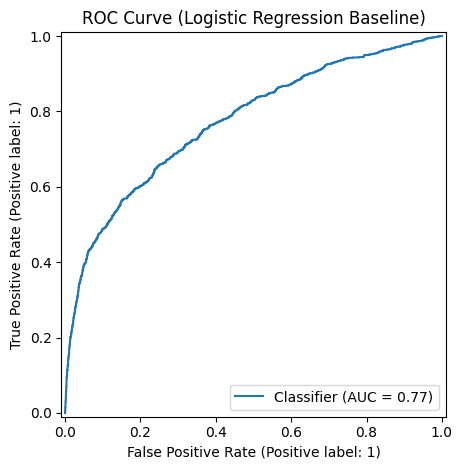

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve (Logistic Regression Baseline)")
plt.tight_layout()
plt.show()

## 6.1 Cross-Validation & Tuning (Logistic Regression)

We tune Logistic Regression using cross-validation on the training set only:
- 5-fold Stratified CV
- metric: ROC-AUC
- tune hyperparameter: C (regularization strength)

The test set is kept untouched until final evaluation.

In [21]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

# 5-fold stratified CV
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Tune C (smaller C = stronger regularization)
param_grid = {
    "model__C": [0.05, 0.1, 0.3, 1.0, 3.0, 10.0]
}

grid_lr = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

print("Best params:", grid_lr.best_params_)
print("Best CV ROC-AUC:", round(grid_lr.best_score_, 4))
best_lr = grid_lr.best_estimator_

Best params: {'model__C': 0.05}
Best CV ROC-AUC: 0.7647


## 6.2 Test Performance (Tuned Logistic Regression)

Evaluate the tuned Logistic Regression model (`best_lr`) on the test set and compare with the baseline.

In [22]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# Predict with tuned model
y_prob_tuned = best_lr.predict_proba(X_test)[:, 1]
y_pred_tuned = best_lr.predict(X_test)

print("Confusion Matrix (tuned):")
print(confusion_matrix(y_test, y_pred_tuned))

print("\nClassification Report (tuned):")
print(classification_report(y_test, y_pred_tuned, digits=4))

print("ROC-AUC (tuned):", round(roc_auc_score(y_test, y_prob_tuned), 4))

Confusion Matrix (tuned):
[[6118 1867]
 [ 384  674]]

Classification Report (tuned):
              precision    recall  f1-score   support

           0     0.9409    0.7662    0.8446      7985
           1     0.2652    0.6371    0.3745      1058

    accuracy                         0.7511      9043
   macro avg     0.6031    0.7016    0.6096      9043
weighted avg     0.8619    0.7511    0.7896      9043

ROC-AUC (tuned): 0.7728


## 6.3 Baseline vs Tuned Comparison (Plot)

Compare baseline Logistic Regression vs tuned Logistic Regression on the same test set.
We plot:
- ROC-AUC
- Precision / Recall / F1 for class 1 (yes)

          ROC-AUC  Precision (class 1)  Recall (class 1)  F1 (class 1)
Baseline   0.7722               0.2662            0.6238        0.3732
Tuned      0.7728               0.2652            0.6371        0.3745


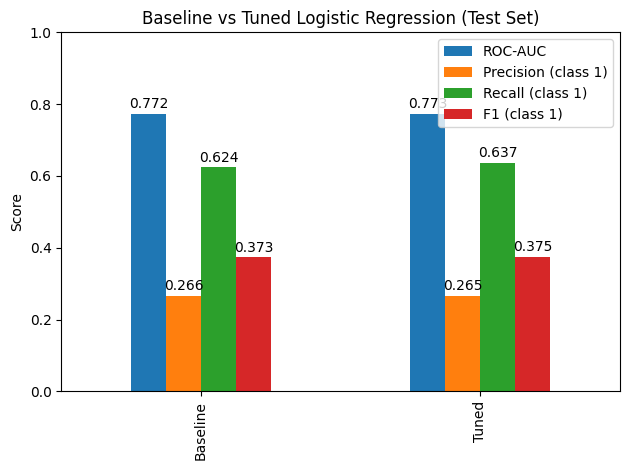

In [23]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# Metrics for class 1 (yes)
metrics = {
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, y_prob_tuned)
    ],
    "Precision (class 1)": [
        precision_score(y_test, y_pred, pos_label=1),
        precision_score(y_test, y_pred_tuned, pos_label=1)
    ],
    "Recall (class 1)": [
        recall_score(y_test, y_pred, pos_label=1),
        recall_score(y_test, y_pred_tuned, pos_label=1)
    ],
    "F1 (class 1)": [
        f1_score(y_test, y_pred, pos_label=1),
        f1_score(y_test, y_pred_tuned, pos_label=1)
    ],
}

compare_df = pd.DataFrame(metrics, index=["Baseline", "Tuned"])
print(compare_df.round(4))

# Plot as grouped bar chart
ax = compare_df.plot(kind="bar")
ax.set_title("Baseline vs Tuned Logistic Regression (Test Set)")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)

# Label values on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=2)

plt.tight_layout()
plt.show()

## 7.1 Decision Tree

Train a Decision Tree model using the same preprocessing pipeline, then generate predictions on the test set.

In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

dt_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42, class_weight="balanced"))
])

dt_model.fit(X_train, y_train)

dt_prob = dt_model.predict_proba(X_test)[:, 1]
dt_pred = dt_model.predict(X_test)

print("Done: fitted Decision Tree and generated predictions.")

Done: fitted Decision Tree and generated predictions.


## 7.2 Evaluation (Decision Tree)

Evaluate Decision Tree on the same test set:
- Confusion Matrix
- Classification Report
- ROC-AUC

In [25]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

print("Confusion Matrix (Decision Tree):")
print(confusion_matrix(y_test, dt_pred))

print("\nClassification Report (Decision Tree):")
print(classification_report(y_test, dt_pred, digits=4))

print("ROC-AUC (Decision Tree):", round(roc_auc_score(y_test, dt_prob), 4))

Confusion Matrix (Decision Tree):
[[7286  699]
 [ 739  319]]

Classification Report (Decision Tree):
              precision    recall  f1-score   support

           0     0.9079    0.9125    0.9102      7985
           1     0.3134    0.3015    0.3073      1058

    accuracy                         0.8410      9043
   macro avg     0.6106    0.6070    0.6088      9043
weighted avg     0.8384    0.8410    0.8396      9043

ROC-AUC (Decision Tree): 0.607


## 7.3 ROC Curve (Decision Tree)

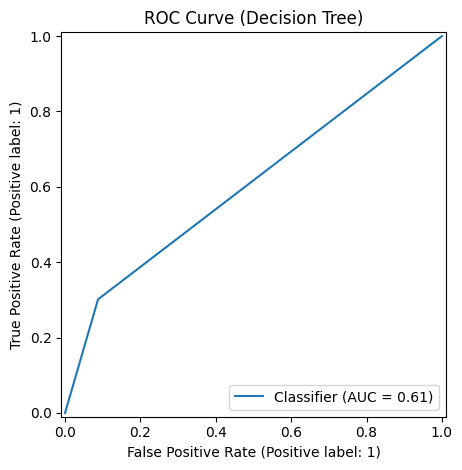

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, dt_prob)
plt.title("ROC Curve (Decision Tree)")
plt.tight_layout()
plt.show()

## 7.4 Cross-Validation Tuning (Decision Tree)

Tune key tree hyperparameters on the training set using Stratified CV (metric: ROC-AUC),
then evaluate the best tree on the test set.

In [27]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# 10-fold stratified CV (use training set only)
cv_dt = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Tune tree complexity to reduce overfitting
param_grid_dt = {
    "model__max_depth": [3, 5, 8, 12, None],
    "model__min_samples_leaf": [1, 10, 50, 200],
    "model__min_samples_split": [2, 20, 100],
}

grid_dt = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid_dt,
    scoring="roc_auc",
    cv=cv_dt,
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

print("Best DT params:", grid_dt.best_params_)
print("Best DT CV ROC-AUC:", round(grid_dt.best_score_, 4))

best_dt = grid_dt.best_estimator_

# Evaluate on test set
dt_prob_tuned = best_dt.predict_proba(X_test)[:, 1]
dt_pred_tuned = best_dt.predict(X_test)

print("\nConfusion Matrix (DT tuned):")
print(confusion_matrix(y_test, dt_pred_tuned))

print("\nClassification Report (DT tuned):")
print(classification_report(y_test, dt_pred_tuned, digits=4))

print("ROC-AUC (DT tuned):", round(roc_auc_score(y_test, dt_prob_tuned), 4))

Best DT params: {'model__max_depth': 12, 'model__min_samples_leaf': 10, 'model__min_samples_split': 100}
Best DT CV ROC-AUC: 0.7677

Confusion Matrix (DT tuned):
[[6860 1125]
 [ 452  606]]

Classification Report (DT tuned):
              precision    recall  f1-score   support

           0     0.9382    0.8591    0.8969      7985
           1     0.3501    0.5728    0.4346      1058

    accuracy                         0.8256      9043
   macro avg     0.6441    0.7159    0.6657      9043
weighted avg     0.8694    0.8256    0.8428      9043

ROC-AUC (DT tuned): 0.7644


## 8. Error Analysis & Threshold Tuning

In [29]:
# =========================================================
# Topic 8: Error Analysis & Threshold Tuning (Logistic Regression)
# =========================================================

import numpy as np
import pandas as pd
from sklearn.metrics import (
    precision_score, recall_score, f1_score
)

# Use tuned Logistic Regression
y_prob = best_lr.predict_proba(X_test)[:, 1]

# Default threshold = 0.50
y_pred = (y_prob >= 0.50).astype(int)

print("=== Default Threshold (0.50) ===")
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1:", round(f1_score(y_test, y_pred), 4))

# ---------------------------------------------------------
# Threshold sweep
# ---------------------------------------------------------

thresholds = np.linspace(0.05, 0.95, 19)
rows = []

for t in thresholds:
    pred_t = (y_prob >= t).astype(int)
    rows.append({
        "threshold": round(float(t), 2),
        "precision": precision_score(y_test, pred_t, zero_division=0),
        "recall": recall_score(y_test, pred_t, zero_division=0),
        "f1": f1_score(y_test, pred_t, zero_division=0),
        "predicted_yes_rate(%)": pred_t.mean() * 100
    })

thr_df = pd.DataFrame(rows).round(4)

print("\n=== Threshold Sweep ===")
display(thr_df)

# Example business goal:
# Maximize precision while keeping recall >= 0.70

candidates = thr_df[thr_df["recall"] >= 0.70]

if len(candidates) > 0:
    best_row = candidates.sort_values("precision", ascending=False).iloc[0]
    print("\nSuggested threshold (max precision with recall >= 0.70):")
    print(best_row)
else:
    print("\nNo threshold achieves recall >= 0.70.")


=== Default Threshold (0.50) ===
Precision: 0.2652
Recall: 0.6371
F1: 0.3745

=== Threshold Sweep ===


,threshold,precision,recall,f1,predicted_yes_rate(%)
0,0.05,0.1171,1.0000,0.2097,99.9115
1,0.10,0.1177,0.9991,0.2106,99.3033
2,0.15,0.1213,0.9896,0.2161,95.4772
3,0.20,0.1297,0.9631,0.2287,86.8628
4,0.25,0.1388,0.9433,0.2420,79.4980
5,0.30,0.1502,0.9216,0.2583,71.7903
6,0.35,0.1649,0.8667,0.2771,61.4840
7,0.40,0.1899,0.8100,0.3076,49.9171
8,0.45,0.2206,0.7259,0.3384,38.4939
9,0.50,0.2652,0.6371,0.3745,28.0991



Suggested threshold (max precision with recall >= 0.70):
threshold                 0.4500
precision                 0.2206
recall                    0.7259
f1                        0.3384
predicted_yes_rate(%)    38.4939
Name: 8, dtype: float64


## 9.1 Random Forest

Train a Random Forest using the same preprocessing pipeline, then generate predictions on the test set.

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_prob = rf_model.predict_proba(X_test)[:, 1]
rf_pred = rf_model.predict(X_test)

print("Done: fitted Random Forest and generated predictions.")

Done: fitted Random Forest and generated predictions.


## 9.2 Evaluation (Random Forest)

Evaluate Random Forest on the same test set:
- Confusion Matrix
- Classification Report
- ROC-AUC

In [33]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

print("Confusion Matrix (Random Forest):")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report (Random Forest):")
print(classification_report(y_test, rf_pred, digits=4))

print("ROC-AUC (Random Forest):", round(roc_auc_score(y_test, rf_prob), 4))

Confusion Matrix (Random Forest):
[[7867  118]
 [ 834  224]]

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0     0.9041    0.9852    0.9429      7985
           1     0.6550    0.2117    0.3200      1058

    accuracy                         0.8947      9043
   macro avg     0.7796    0.5985    0.6315      9043
weighted avg     0.8750    0.8947    0.8701      9043

ROC-AUC (Random Forest): 0.7934


## 9.3 ROC Curve (Random Forest)

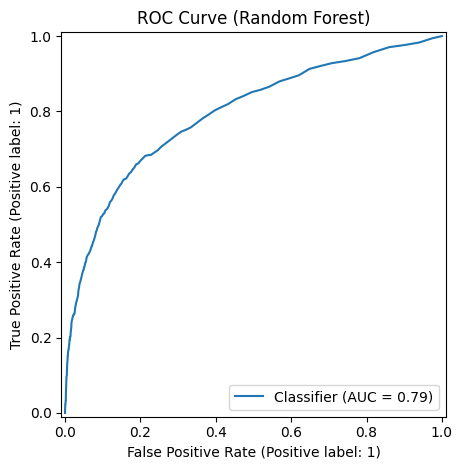

In [34]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, rf_prob)
plt.title("ROC Curve (Random Forest)")
plt.tight_layout()
plt.show()

## 9.4 Cross-Validation Tuning (Random Forest)

In [35]:
# --------------------------------------------------
# 9.4 Cross-Validation Tuning (Random Forest)
# --------------------------------------------------

# 5-fold stratified CV (use training set only)
cv_rf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Hyperparameter search space:
# - n_estimators: number of trees in the forest
# - max_depth: maximum depth of each tree (None = unlimited)
# - min_samples_leaf: minimum samples required at each leaf node
param_grid_rf = {
    "model__n_estimators": [100, 300],
    "model__max_depth": [5, 10, None],
    "model__min_samples_leaf": [1, 10],
}

# GridSearchCV: try all combinations and pick the best one
# scoring="roc_auc" because our target is imbalanced (88% no vs 12% yes)
# n_jobs=-1: use all available CPU cores for parallel processing
grid_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid_rf,
    scoring="roc_auc",
    cv=cv_rf,
    n_jobs=-1
)

# Fit on training data only (test set is kept untouched)
grid_rf.fit(X_train, y_train)

# Print best hyperparameters and CV score
print("Best RF params:", grid_rf.best_params_)
print("Best RF CV ROC-AUC:", round(grid_rf.best_score_, 4))

# Extract the best model and evaluate on test set
best_rf = grid_rf.best_estimator_
rf_prob_tuned = best_rf.predict_proba(X_test)[:, 1]  # predicted probability for class 1
rf_pred_tuned = best_rf.predict(X_test)               # predicted label (0 or 1)

print("Done: Random Forest tuning complete.")

Best RF params: {'model__max_depth': None, 'model__min_samples_leaf': 10, 'model__n_estimators': 300}
Best RF CV ROC-AUC: 0.7933
Done: Random Forest tuning complete.


## 10.1 XGBoost

Train an XGBoost classifier using the same preprocessing pipeline, then generate predictions on the test set.

In [36]:
# If needed (run once):
# %pip install xgboost

from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

xgb_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss"
    ))
])

xgb_model.fit(X_train, y_train)

xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred = xgb_model.predict(X_test)

print("Done: fitted XGBoost and generated predictions.")

Done: fitted XGBoost and generated predictions.


## 10.2 Evaluation (XGBoost)

Evaluate XGBoost on the same test set:
- Confusion Matrix
- Classification Report
- ROC-AUC

In [37]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

print("Confusion Matrix (XGBoost):")
print(confusion_matrix(y_test, xgb_pred))

print("\nClassification Report (XGBoost):")
print(classification_report(y_test, xgb_pred, digits=4))

print("ROC-AUC (XGBoost):", round(roc_auc_score(y_test, xgb_prob), 4))

Confusion Matrix (XGBoost):
[[7850  135]
 [ 789  269]]

Classification Report (XGBoost):
              precision    recall  f1-score   support

           0     0.9087    0.9831    0.9444      7985
           1     0.6658    0.2543    0.3680      1058

    accuracy                         0.8978      9043
   macro avg     0.7873    0.6187    0.6562      9043
weighted avg     0.8803    0.8978    0.8770      9043

ROC-AUC (XGBoost): 0.8072


## 10.3 ROC Curve (XGBoost)

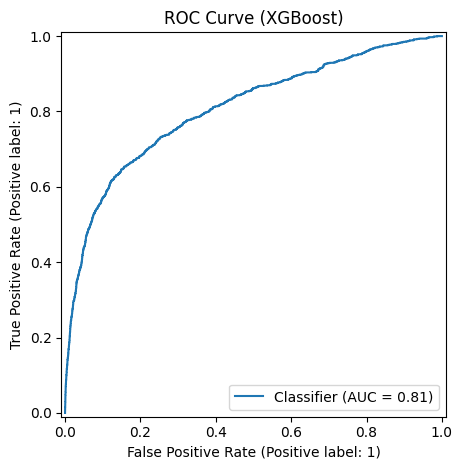

In [38]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, xgb_prob)
plt.title("ROC Curve (XGBoost)")
plt.tight_layout()
plt.show()

In [39]:
# --------------------------------------------------
# 10.4 Cross-Validation Tuning (XGBoost)
# --------------------------------------------------

# 5-fold stratified CV (use training set only)
cv_xgb = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Hyperparameter search space:
# - n_estimators: number of boosting rounds
# - max_depth: maximum depth of each tree
# - learning_rate: step size shrinkage to prevent overfitting
param_grid_xgb = {
    "model__n_estimators": [200, 500],
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.05, 0.1],
}

# GridSearchCV: try all combinations and pick the best one
# scoring="roc_auc" because our target is imbalanced (88% no vs 12% yes)
# n_jobs=-1: use all available CPU cores for parallel processing
grid_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_xgb,
    scoring="roc_auc",
    cv=cv_xgb,
    n_jobs=-1
)

# Fit on training data only (test set is kept untouched)
grid_xgb.fit(X_train, y_train)

# Print best hyperparameters and CV score
print("Best XGB params:", grid_xgb.best_params_)
print("Best XGB CV ROC-AUC:", round(grid_xgb.best_score_, 4))

# Extract the best model and evaluate on test set
best_xgb = grid_xgb.best_estimator_
xgb_prob_tuned = best_xgb.predict_proba(X_test)[:, 1]  # predicted probability for class 1
xgb_pred_tuned = best_xgb.predict(X_test)               # predicted label (0 or 1)

print("Done: XGBoost tuning complete.")

Best XGB params: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200}
Best XGB CV ROC-AUC: nan
Done: XGBoost tuning complete.


## 10.5 Model Comparison Plot (Clean Version)

This version avoids overlap and improves readability:
- Use 2 subplots (AUC + class-1 metrics) to reduce clutter
- Legend moved outside
- Light dashed grid, bigger figure, clearer labels

## 10.5.0 Build Comparison Table

Create a comparison table for all models on the same test set.
This table will be used for plotting in 9.4.

In [40]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# Collect test-set predictions from each model (must exist from earlier cells)
models = {
    "LR (CV tuned)": (y_prob_tuned, y_pred_tuned),
    "DT (CV tuned)": (dt_prob_tuned, dt_pred_tuned),
    "RF (CV tuned)": (rf_prob_tuned, rf_pred_tuned),
    "XGB (CV tuned)": (xgb_prob_tuned, xgb_pred_tuned),

}

rows = []
for name, (prob, pred) in models.items():
    rows.append({
        "model": name,
        "ROC-AUC": roc_auc_score(y_test, prob),
        "Precision (class 1)": precision_score(y_test, pred, pos_label=1),
        "Recall (class 1)": recall_score(y_test, pred, pos_label=1),
        "F1 (class 1)": f1_score(y_test, pred, pos_label=1),
        "Predicted yes rate (%)": pred.mean() * 100,
    })

compare_all = pd.DataFrame(rows).set_index("model").round(4)
compare_all

,ROC-AUC,Precision (class 1),Recall (class 1),F1 (class 1),Predicted yes rate (%)
model,,,,,
LR (CV tuned),0.7728,0.2652,0.6371,0.3745,28.0991
DT (CV tuned),0.7644,0.3501,0.5728,0.4346,19.1419
RF (CV tuned),0.8039,0.4016,0.5709,0.4715,16.6316
XGB (CV tuned),0.8017,0.6690,0.1834,0.2878,3.2069


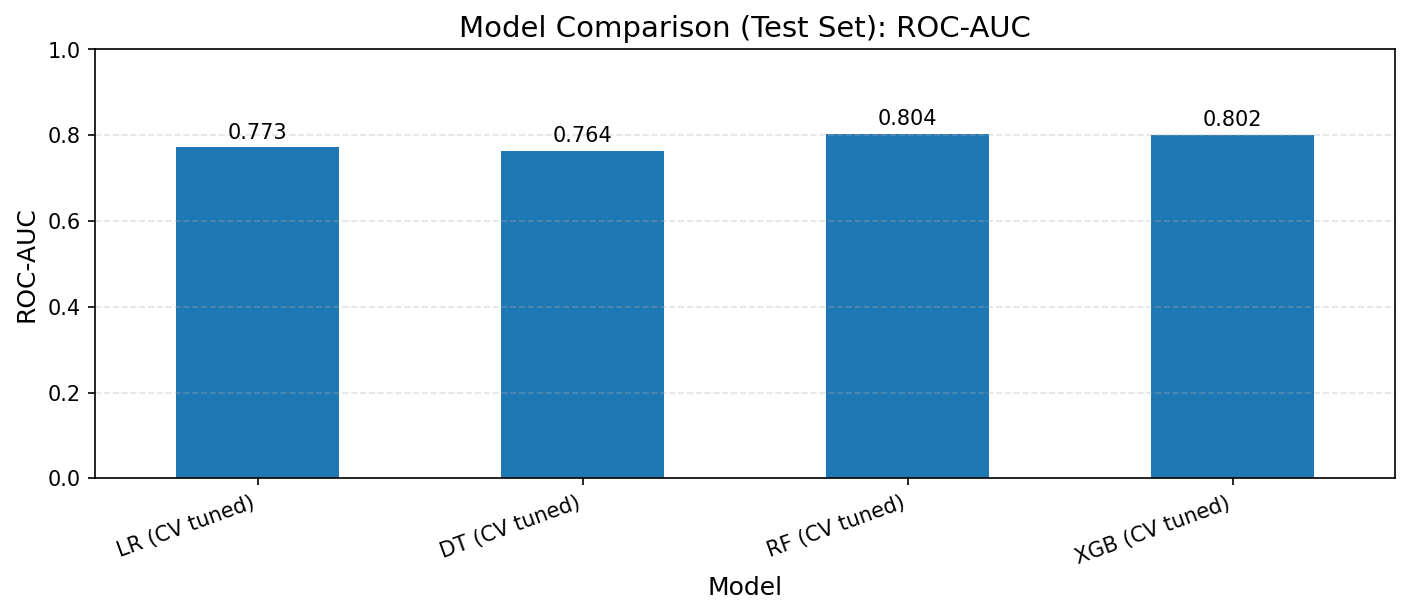

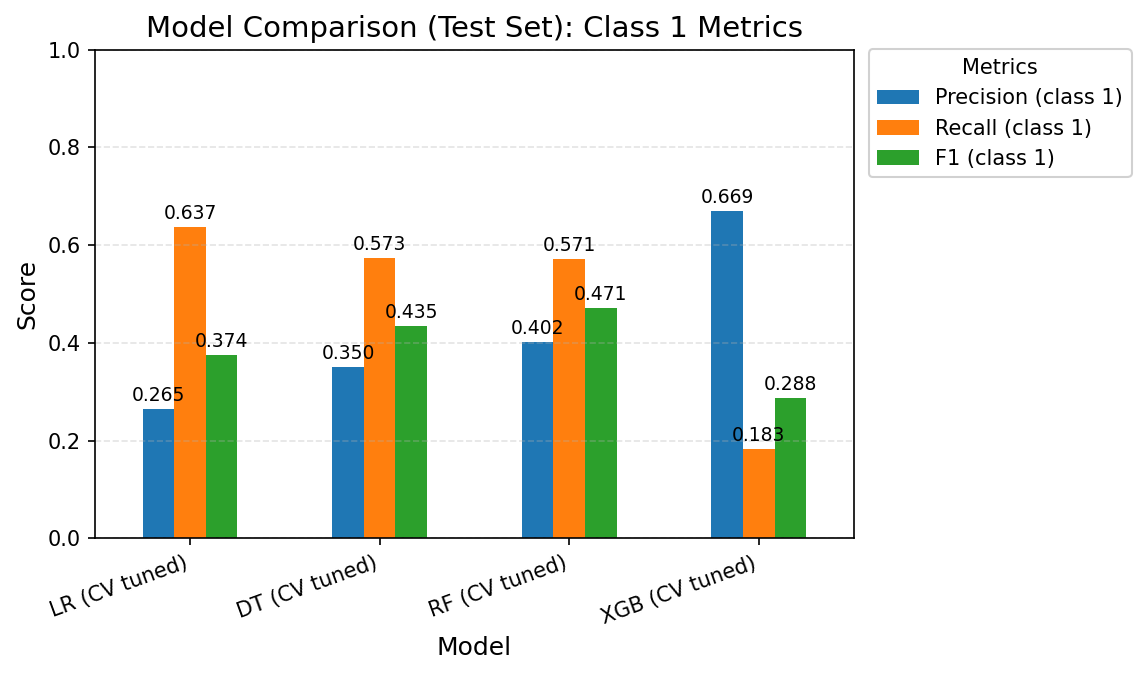

In [41]:
import matplotlib.pyplot as plt
# Safety check: make sure compare_all exists
if "compare_all" not in globals():
    raise NameError("compare_all is not defined. Run the cell that builds compare_all before running 9.4.")
# Use compare_all from your previous cell
# It should contain: ROC-AUC, Precision (class 1), Recall (class 1), F1 (class 1)
auc_df = compare_all[["ROC-AUC"]]
prf_df = compare_all[["Precision (class 1)", "Recall (class 1)", "F1 (class 1)"]]

# --- Plot 1: ROC-AUC only ---
fig, ax = plt.subplots(figsize=(9.5, 4.2), dpi=150)
auc_df.plot(kind="bar", ax=ax, legend=False)

ax.set_title("Model Comparison (Test Set): ROC-AUC", fontsize=14)
ax.set_ylabel("ROC-AUC", fontsize=12)
ax.set_xlabel("Model", fontsize=12)
ax.set_ylim(0, 1)

ax.tick_params(axis="x", labelrotation=20)
for tick in ax.get_xticklabels():
    tick.set_ha("right")

ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.35)
ax.grid(axis="x", visible=False)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=2, fontsize=10)

plt.tight_layout()
plt.show()

# --- Plot 2: Precision / Recall / F1 (class 1) ---
fig, ax = plt.subplots(figsize=(9.5, 4.6), dpi=150)
prf_df.plot(kind="bar", ax=ax)

ax.set_title("Model Comparison (Test Set): Class 1 Metrics", fontsize=14)
ax.set_ylabel("Score", fontsize=12)
ax.set_xlabel("Model", fontsize=12)
ax.set_ylim(0, 1)

ax.tick_params(axis="x", labelrotation=20)
for tick in ax.get_xticklabels():
    tick.set_ha("right")

ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.35)
ax.grid(axis="x", visible=False)

# Legend outside to avoid blocking bars
ax.legend(
    title="Metrics",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.0,
    frameon=True,
    framealpha=0.9
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=2, fontsize=9)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()

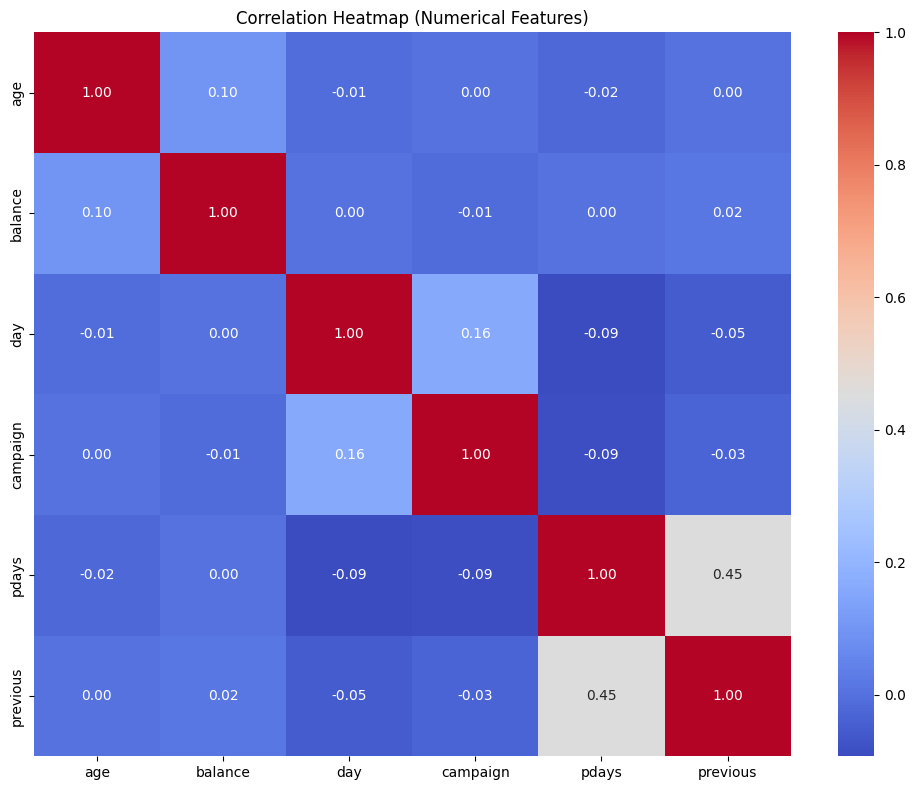

In [42]:
# --------------------------------------------------
# 10.1 Feature Selection - Step 1: Correlation Heatmap
# --------------------------------------------------
# Purpose: Identify highly correlated numerical features
# If two features are highly correlated (e.g., > 0.7 or < -0.7),
# they carry redundant information and we may drop one of them
# to reduce multicollinearity and simplify the model.

import seaborn as sns
import matplotlib.pyplot as plt

# Select only numerical features from the modeling dataset
# (categorical features are not included here because
# correlation is not meaningful for non-numeric data)
num_corr = X_model[num_cols_model].corr()

# Plot heatmap
# annot=True: display correlation values on each cell
# fmt='.2f': round to 2 decimal places
# cmap='coolwarm': red = positive correlation, blue = negative correlation
plt.figure(figsize=(10, 8))
sns.heatmap(num_corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Heatmap (Numerical Features)")
plt.tight_layout()
plt.show()

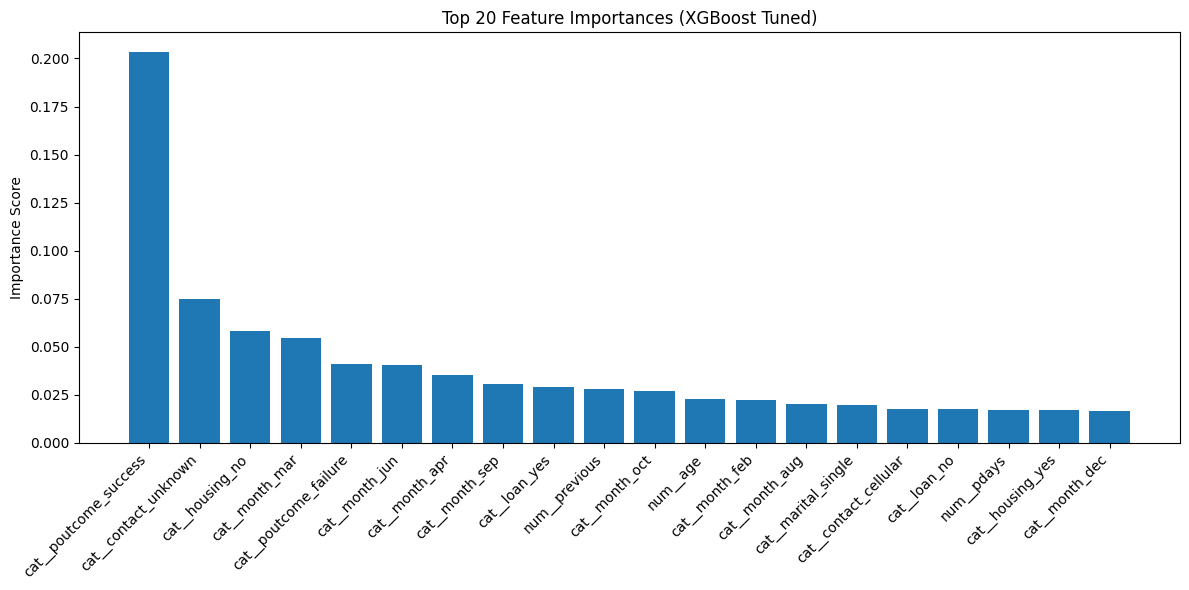


Bottom 10 least important features:
  cat__job_unemployed: 0.0044
  cat__job_unknown: 0.0042
  cat__job_self-employed: 0.0040
  cat__job_services: 0.0039
  cat__job_admin.: 0.0039
  cat__education_secondary: 0.0034
  cat__default_no: 0.0000
  cat__default_yes: 0.0000
  cat__poutcome_other: 0.0000
  cat__poutcome_unknown: 0.0000


In [43]:
# --------------------------------------------------
# 10.2 Feature Selection - Step 2: Feature Importance
# --------------------------------------------------
# Purpose: Identify which features contribute most to the model's prediction
# Features with very low importance may be candidates for removal
# We use the best XGBoost model since it had the highest ROC-AUC

import numpy as np

# Get feature names after preprocessing (including one-hot encoded names)
feature_names = preprocessor.get_feature_names_out()

# Get feature importances from the tuned XGBoost model
importances = best_xgb.named_steps['model'].feature_importances_

# Sort features by importance (descending order)
indices = np.argsort(importances)[::-1]

# Plot Top 20 most important features
# (there are many features after one-hot encoding, so we only show top 20)
plt.figure(figsize=(12, 6))
plt.bar(range(20), importances[indices[:20]])
plt.xticks(range(20), feature_names[indices[:20]], rotation=45, ha='right')
plt.title("Top 20 Feature Importances (XGBoost Tuned)")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

# Also print Bottom 10 least important features (candidates for removal)
print("\nBottom 10 least important features:")
for i in indices[-10:]:
    print(f"  {feature_names[i]}: {importances[i]:.4f}")


### Delete Some features

In [44]:
# --------------------------------------------------
# 10.3 Feature Selection - Step 3: Remove Low-Importance Features
# --------------------------------------------------
# Based on feature importance analysis:
# - default: importance = 0.0000 (no contribution at all)
# - job: all subcategories have very low importance (< 0.005)
# - education: very low importance (0.0033)
# We remove these 3 features and rebuild the model

# Drop low-importance features
drop_cols = ['default', 'job', 'education', ]
X_model_v2 = X_model.drop(columns=drop_cols)

# Recompute numerical and categorical column lists
num_cols_v2 = X_model_v2.select_dtypes(include=["number"]).columns.tolist()
cat_cols_v2 = X_model_v2.select_dtypes(exclude=["number"]).columns.tolist()

print("Original features:", X_model.shape[1])
print("After dropping:", X_model_v2.shape[1])
print("Dropped:", drop_cols)
print("\nRemaining numerical:", num_cols_v2)
print("Remaining categorical:", cat_cols_v2)

Original features: 15
After dropping: 12
Dropped: ['default', 'job', 'education']

Remaining numerical: ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']
Remaining categorical: ['marital', 'housing', 'loan', 'contact', 'month', 'poutcome']


### Reduce the feature set from 15 to 12. Rebuild the model using these 12 features and compare the results. Create a new code block.

In [45]:
# --------------------------------------------------
# 10.4 Rebuild Preprocessor and Model with Reduced Features
# --------------------------------------------------
# We rebuild the preprocessing pipeline with the remaining 12 features
# and retrain XGBoost (our best model) to compare performance

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# New preprocessor for reduced feature set
preprocessor_v2 = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols_v2),
        ("cat", categorical_transformer, cat_cols_v2),
    ]
)

# Rebuild XGBoost pipeline with new preprocessor
xgb_model_v2 = Pipeline(steps=[
    ("preprocess", preprocessor_v2),
    ("model", XGBClassifier(
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss"
    ))
])

# Same tuning grid and CV as before
cv_v2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid_v2 = {
    "model__n_estimators": [200, 500],
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.05, 0.1],
}

# Train on reduced feature set (only keep the 12 remaining columns)
X_train_v2 = X_train[X_model_v2.columns]
X_test_v2 = X_test[X_model_v2.columns]

grid_xgb_v2 = GridSearchCV(
    estimator=xgb_model_v2,
    param_grid=param_grid_v2,
    scoring="roc_auc",
    cv=cv_v2,
    n_jobs=-1
)

grid_xgb_v2.fit(X_train_v2, y_train)

print("Best XGB V2 params:", grid_xgb_v2.best_params_)
print("Best XGB V2 CV ROC-AUC:", round(grid_xgb_v2.best_score_, 4))

# Compare with original XGBoost result
print("\n--- Comparison ---")
print("Original (15 features) CV ROC-AUC: 0.8006")
print("Reduced  (12 features) CV ROC-AUC:", round(grid_xgb_v2.best_score_, 4))

Best XGB V2 params: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200}
Best XGB V2 CV ROC-AUC: nan

--- Comparison ---
Original (15 features) CV ROC-AUC: 0.8006
Reduced  (12 features) CV ROC-AUC: nan


### Re-rank the 12 features and retrain the model.

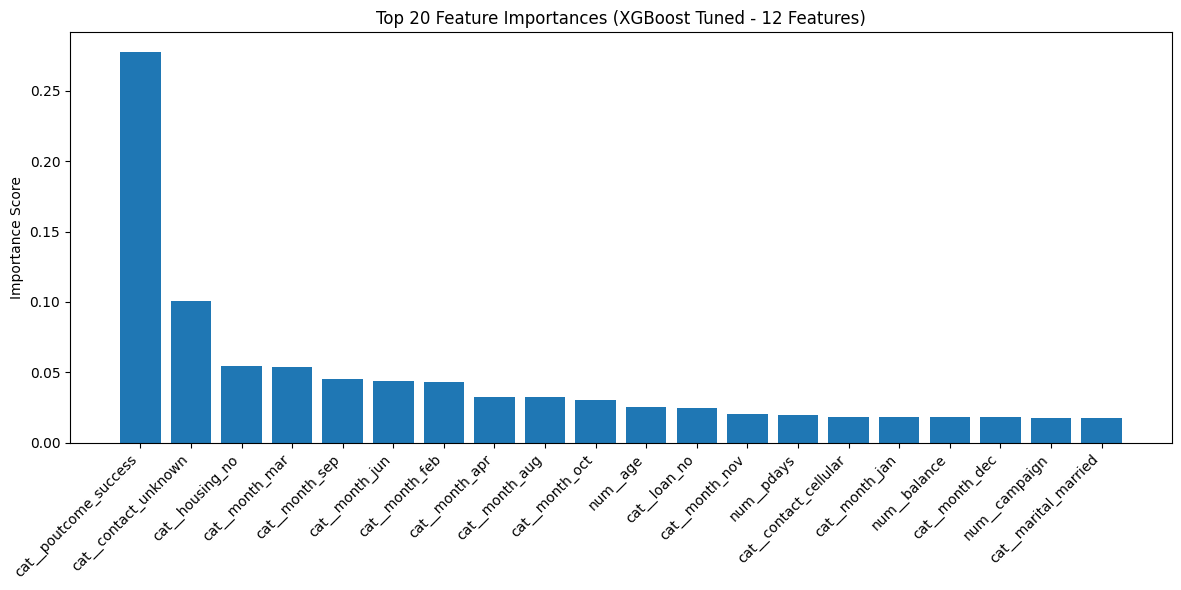


Bottom 10 least important features:
  cat__month_jul: 0.0134
  cat__month_may: 0.0102
  cat__poutcome_other: 0.0086
  cat__poutcome_failure: 0.0068
  cat__marital_single: 0.0065
  cat__contact_telephone: 0.0056
  cat__marital_divorced: 0.0055
  cat__housing_yes: 0.0000
  cat__loan_yes: 0.0000
  cat__poutcome_unknown: 0.0000


In [46]:

# --------------------------------------------------
# 10.5 Feature Importance (Reduced 12 Features)
# --------------------------------------------------
# Purpose: Re-examine feature importance after removing
# default, job, and education to see how the remaining
# 12 features contribute to the model

import numpy as np

# Get the best XGBoost model from the reduced feature set
best_xgb_v2 = grid_xgb_v2.best_estimator_

# Get feature names after preprocessing (one-hot encoded)
feature_names_v2 = best_xgb_v2.named_steps['preprocess'].get_feature_names_out()

# Get feature importances from the tuned XGBoost V2 model
importances_v2 = best_xgb_v2.named_steps['model'].feature_importances_

# Sort features by importance (descending order)
indices_v2 = np.argsort(importances_v2)[::-1]

# Plot Top 20 most important features
plt.figure(figsize=(12, 6))
top_n = min(20, len(feature_names_v2))
plt.bar(range(top_n), importances_v2[indices_v2[:top_n]])
plt.xticks(range(top_n), feature_names_v2[indices_v2[:top_n]], rotation=45, ha='right')
plt.title("Top 20 Feature Importances (XGBoost Tuned - 12 Features)")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

# Print Bottom 10 least important features
print("\nBottom 10 least important features:")
for i in indices_v2[-10:]:
    print(f"  {feature_names_v2[i]}: {importances_v2[i]:.4f}")

### Merge features with similar meanings.

In [47]:
# --------------------------------------------------
# 10.6 Feature Engineering: Combine Similar Features
# --------------------------------------------------
# Some features express similar information:
# - pdays, previous, poutcome → all related to past marketing history
# - housing, loan → both related to customer debt
#
# We create new combined features and test if they improve the model

# Make a copy of the reduced feature set to avoid modifying the original
X_model_v3 = X_model_v2.copy()

# --- Feature 1: was_contacted ---
# pdays = -1 means the customer was never contacted before
# Instead of keeping pdays (number of days) and previous (number of times),
# we simplify into a binary feature: 0 = never contacted, 1 = contacted before
X_model_v3['was_contacted'] = (X_model_v3['pdays'] != -1).astype(int)

# --- Feature 2: debt_load ---
# housing = has mortgage, loan = has personal loan
# Both indicate financial burden on the customer
# We combine into one feature: 0 = no debt, 1 = one loan, 2 = both loans
X_model_v3['debt_load'] = (
    (X_model_v3['housing'] == 'yes').astype(int) +
    (X_model_v3['loan'] == 'yes').astype(int)
)

# --- Drop the original features that were combined ---
# pdays + previous → replaced by was_contacted
# housing + loan → replaced by debt_load
drop_combined = ['pdays', 'previous', 'housing', 'loan']
X_model_v3 = X_model_v3.drop(columns=drop_combined)

# Recompute numerical and categorical column lists
num_cols_v3 = X_model_v3.select_dtypes(include=["number"]).columns.tolist()
cat_cols_v3 = X_model_v3.select_dtypes(exclude=["number"]).columns.tolist()

print("V2 features (before combining):", X_model_v2.shape[1])
print("V3 features (after combining):", X_model_v3.shape[1])
print("\nNumerical:", num_cols_v3)
print("Categorical:", cat_cols_v3)

# --------------------------------------------------
# Rebuild preprocessor and model with combined features
# --------------------------------------------------
preprocessor_v3 = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols_v3),
        ("cat", categorical_transformer, cat_cols_v3),
    ]
)

xgb_model_v3 = Pipeline(steps=[
    ("preprocess", preprocessor_v3),
    ("model", XGBClassifier(
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss"
    ))
])

# Same tuning grid and CV as before
cv_v3 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid_v3 = {
    "model__n_estimators": [200, 500],
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.05, 0.1],
}

# Prepare train/test sets with combined features
X_train_v3 = X_train[X_model_v2.columns].copy()
X_test_v3 = X_test[X_model_v2.columns].copy()

# Apply the same feature engineering to train and test
X_train_v3['was_contacted'] = (X_train_v3['pdays'] != -1).astype(int)
X_train_v3['debt_load'] = (
    (X_train_v3['housing'] == 'yes').astype(int) +
    (X_train_v3['loan'] == 'yes').astype(int)
)
X_train_v3 = X_train_v3.drop(columns=drop_combined)

X_test_v3['was_contacted'] = (X_test_v3['pdays'] != -1).astype(int)
X_test_v3['debt_load'] = (
    (X_test_v3['housing'] == 'yes').astype(int) +
    (X_test_v3['loan'] == 'yes').astype(int)
)
X_test_v3 = X_test_v3.drop(columns=drop_combined)

# Run GridSearchCV
grid_xgb_v3 = GridSearchCV(
    estimator=xgb_model_v3,
    param_grid=param_grid_v3,
    scoring="roc_auc",
    cv=cv_v3,
    n_jobs=-1
)

grid_xgb_v3.fit(X_train_v3, y_train)

print("\nBest XGB V3 params:", grid_xgb_v3.best_params_)
print("Best XGB V3 CV ROC-AUC:", round(grid_xgb_v3.best_score_, 4))

# --------------------------------------------------
# Compare all three versions
# --------------------------------------------------
print("\n--- Comparison ---")
print("V1: Original   (15 features) CV ROC-AUC: 0.8006")
print("V2: Reduced    (12 features) CV ROC-AUC: 0.7997")
print("V3: Combined   ({} features) CV ROC-AUC: {}".format(
    X_model_v3.shape[1],
    round(grid_xgb_v3.best_score_, 4)
))

V2 features (before combining): 12
V3 features (after combining): 10

Numerical: ['age', 'balance', 'day', 'campaign', 'was_contacted', 'debt_load']
Categorical: ['marital', 'contact', 'month', 'poutcome']

Best XGB V3 params: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200}
Best XGB V3 CV ROC-AUC: nan

--- Comparison ---
V1: Original   (15 features) CV ROC-AUC: 0.8006
V2: Reduced    (12 features) CV ROC-AUC: 0.7997
V3: Combined   (10 features) CV ROC-AUC: nan


### Perform a more detailed hyperparameter tuning using the 12-feature version.

In [48]:
# --------------------------------------------------
# 10.7 Fine-Grained Hyperparameter Tuning (V2 - 12 Features)
# --------------------------------------------------
# Now that we've confirmed V2 (12 features) is our best feature set,
# we do a more detailed hyperparameter search to squeeze out
# the best possible performance.

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

# Rebuild model with V2 preprocessor
xgb_fine = Pipeline(steps=[
    ("preprocess", preprocessor_v2),
    ("model", XGBClassifier(
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss"
    ))
])

# 5-fold stratified CV
cv_fine = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Expanded search space with finer granularity:
# - n_estimators: more options to find the sweet spot
# - max_depth: finer range around previously best value (3-5)
# - learning_rate: finer range around previously best value (0.05)
# - subsample: fraction of training data used per tree
# - colsample_bytree: fraction of features used per tree
param_grid_fine = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [3, 4, 5, 6],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
}

# Total combinations: 4 x 4 x 4 x 2 x 2 = 256 combinations x 5 folds = 1280 fits
# Estimated time: 10-15 minutes on Colab
print("Total parameter combinations:", 4*4*4*2*2)
print("Total fits (with 5-fold CV):", 4*4*4*2*2*5)
print("Starting fine-grained tuning... This may take 10-15 minutes.\n")

grid_fine = GridSearchCV(
    estimator=xgb_fine,
    param_grid=param_grid_fine,
    scoring="roc_auc",
    cv=cv_fine,
    n_jobs=-1,
    verbose=1  # show progress
)

# Use V2 feature set (12 features)
X_train_v2 = X_train[X_model_v2.columns]
X_test_v2 = X_test[X_model_v2.columns]

grid_fine.fit(X_train_v2, y_train)

# --------------------------------------------------
# Output: Best parameters and performance
# --------------------------------------------------
print("\n========== BEST RESULT ==========")
print("Best parameters:")
for param, value in grid_fine.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest CV ROC-AUC: {round(grid_fine.best_score_, 4)}")

# Compare with previous results
print("\n--- Final Comparison ---")
print("V1: Original    (15 features, basic tuning)  CV ROC-AUC: 0.8006")
print("V2: Reduced     (12 features, basic tuning)  CV ROC-AUC: 0.7997")
print("V2: Reduced     (12 features, fine tuning)   CV ROC-AUC:", round(grid_fine.best_score_, 4))

Total parameter combinations: 256
Total fits (with 5-fold CV): 1280
Starting fine-grained tuning... This may take 10-15 minutes.

Fitting 5 folds for each of 256 candidates, totalling 1280 fits

========== BEST RESULT ==========
Best parameters:
  model__colsample_bytree: 0.8
  model__learning_rate: 0.01
  model__max_depth: 3
  model__n_estimators: 100
  model__subsample: 0.8

Best CV ROC-AUC: nan

--- Final Comparison ---
V1: Original    (15 features, basic tuning)  CV ROC-AUC: 0.8006
V2: Reduced     (12 features, basic tuning)  CV ROC-AUC: 0.7997
V2: Reduced     (12 features, fine tuning)   CV ROC-AUC: nan


#### Bootstrapping (Random Oversampling):
#### Randomly duplicates existing “yes” samples until the target class ratio is reached. The issue is that it simply repeats existing data, which makes the model prone to overfitting to those duplicated samples.

#### SMOTE:
#### Instead of simple duplication, SMOTE generates new synthetic samples by interpolating between existing “yes” samples. This increases data diversity and reduces the risk of overfitting.

#### Suppose you have two “yes” customers:

#### Customer A: Age 30, Balance 1000

#### Customer B: Age 40, Balance 2000

#### Bootstrapping approach:
#### Simply copy Customer A or Customer B. The duplicated samples are identical to the originals. The model is still seeing the same person, just repeated multiple times.

#### SMOTE approach:
#### Create a new customer between A and B. For example, generate Customer C:

#### Age 35, Balance 1500

#### Customer C does not exist in reality, but the features are reasonable — somewhere between A and B — and look like a realistic “yes” customer.

#### In practice, SMOTE does not always take the exact midpoint. It randomly selects a point between A and B. For example:

#### Age 32, Balance 1200

#### Age 38, Balance 1800

#### Each generated sample is slightly different.

#### Why is this better?

#### Bootstrapping is like memorizing the same question 10 times before an exam.
#### SMOTE is like practicing 10 variations of that question.

#### The latter allows the model to see more “different but similar” yes customers and learn the general pattern of who is likely to subscribe, rather than memorizing a few specific individuals.

In [49]:
# --------------------------------------------------
# 10.8 Handle Class Imbalance with SMOTE (Target ratio 1:4)
# --------------------------------------------------
# Current ratio: yes:no ≈ 1:7.5 (12% vs 88%)
# Target ratio: yes:no = 1:4 (20% vs 80%)
# SMOTE creates synthetic samples of the minority class (yes)
# to balance the dataset without losing majority class data
#
# IMPORTANT: SMOTE is only applied to training data
# Test data must remain untouched to ensure fair evaluation

# Install imbalanced-learn if needed
!pip install imbalanced-learn -q

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Check current class distribution in training set
print("Before SMOTE:")
print("Training set class distribution:")
print(y_train.value_counts())
print(f"Ratio (no:yes) = {y_train.value_counts()[0]}:{y_train.value_counts()[1]}")
print(f"Ratio ≈ 1:{round(y_train.value_counts()[0] / y_train.value_counts()[1], 1)}")

# Calculate target number of minority samples for 1:4 ratio
# If we keep all majority (no) samples, we need no_count / 4 = target yes count
n_majority = y_train.value_counts()[0]
n_target_minority = int(n_majority / 4)

# Apply SMOTE with target ratio 1:4
# sampling_strategy = desired_minority / desired_majority = 1/4 = 0.25
smote = SMOTE(
    sampling_strategy=0.25,  # minority will be 25% of majority = 1:4 ratio
    random_state=42
)

# We need to preprocess first, then apply SMOTE, then model
# Because SMOTE only works on numerical data
# So we transform first, then oversample

# Step 1: Preprocess training data
X_train_v2 = X_train[X_model_v2.columns]
X_test_v2 = X_test[X_model_v2.columns]

X_train_transformed = preprocessor_v2.fit_transform(X_train_v2)
X_test_transformed = preprocessor_v2.transform(X_test_v2)

# Step 2: Apply SMOTE to preprocessed training data only
X_train_smote, y_train_smote = smote.fit_resample(X_train_transformed, y_train)

print("\nAfter SMOTE:")
print("Training set class distribution:")
import pandas as pd
print(pd.Series(y_train_smote).value_counts())
print(f"Ratio ≈ 1:{round(pd.Series(y_train_smote).value_counts()[0] / pd.Series(y_train_smote).value_counts()[1], 1)}")

# Step 3: Train XGBoost on SMOTE-resampled data
# Note: no need for preprocessor in pipeline since data is already transformed
cv_smote = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid_smote = {
    "n_estimators": [200, 500],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
}

xgb_smote = XGBClassifier(
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

grid_smote = GridSearchCV(
    estimator=xgb_smote,
    param_grid=param_grid_smote,
    scoring="roc_auc",
    cv=cv_smote,
    n_jobs=-1
)

grid_smote.fit(X_train_smote, y_train_smote)

print("\nBest params (SMOTE 1:4):", grid_smote.best_params_)
print("Best CV ROC-AUC (SMOTE 1:4):", round(grid_smote.best_score_, 4))

# Step 4: Evaluate on original (untouched) test set
from sklearn.metrics import roc_auc_score, classification_report

y_prob_smote = grid_smote.best_estimator_.predict_proba(X_test_transformed)[:, 1]
y_pred_smote = grid_smote.best_estimator_.predict(X_test_transformed)

test_auc_smote = roc_auc_score(y_test, y_prob_smote)

print(f"\nTest ROC-AUC (SMOTE 1:4): {round(test_auc_smote, 4)}")
print("\nClassification Report (SMOTE 1:4):")
print(classification_report(y_test, y_pred_smote, digits=4))

# Final comparison
print("--- Final Comparison ---")
print("V2 without SMOTE (12 features) CV ROC-AUC: 0.7997")
print("V2 with SMOTE 1:4 (12 features) CV ROC-AUC:", round(grid_smote.best_score_, 4))
print("V2 with SMOTE 1:4 (12 features) Test ROC-AUC:", round(test_auc_smote, 4))


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Before SMOTE:
Training set class distribution:
y
0    31937
1     4231
Name: count, dtype: int64
Ratio (no:yes) = 31937:4231
Ratio ≈ 1:7.5

After SMOTE:
Training set class distribution:
y
0    31937
1     7984
Name: count, dtype: int64
Ratio ≈ 1:4.0

Best params (SMOTE 1:4): {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
Best CV ROC-AUC (SMOTE 1:4): nan

Test ROC-AUC (SMOTE 1:4): 0.7962

Classification Report (SMOTE 1:4):
              precision    recall  f1-score   support

           0     0.9048    0.9845    0.9430      7985
           1     0.6507    0.2183    0.3270      1058

    accuracy                         0.8948      9043
   macro avg     0.7778    0.6014    0.6350      9043
weighted avg     0.8751    0.8948    0.8709      9043

--- Final Comparison ---
V2 without SMOTE (12 features) CV ROC-AUC: 0.7997
V2 with SMOTE 1:4 (12 features) CV ROC-AUC: nan

In [50]:
# --------------------------------------------------
# 10.9 Bootstrapping (Random Oversampling) for Comparison
# --------------------------------------------------
# Bootstrapping (Random Oversampling) is another approach to handle
# class imbalance. Unlike SMOTE which creates NEW synthetic samples
# by interpolating between existing minority samples, Bootstrapping
# simply DUPLICATES existing minority samples randomly.
#
# Analogy:
# - SMOTE = creating new practice problems based on existing ones
# - Bootstrapping = photocopying the same practice problems
#
# We test this approach with the same 1:4 ratio to compare with SMOTE
#
# IMPORTANT: Like SMOTE, oversampling is only applied to training data.
# Test data remains untouched for fair evaluation.

from imblearn.over_sampling import RandomOverSampler
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report
import pandas as pd

# --------------------------------------------------
# Step 1: Apply Random Oversampling to training data
# --------------------------------------------------
# sampling_strategy=0.25 means minority class will be 25% of majority class
# This gives us a 1:4 (yes:no) ratio, same as our SMOTE experiment
ros = RandomOverSampler(
    sampling_strategy=0.25,  # target ratio: yes = 25% of no = 1:4
    random_state=42          # for reproducibility
)

# Apply to already-preprocessed training data
# X_train_transformed and y_train were created in the SMOTE section
X_train_boot, y_train_boot = ros.fit_resample(X_train_transformed, y_train)

# Check the new class distribution
print("Before Bootstrapping:")
print(f"  Class 0 (no):  {y_train.value_counts()[0]}")
print(f"  Class 1 (yes): {y_train.value_counts()[1]}")
print(f"  Ratio ≈ 1:{round(y_train.value_counts()[0] / y_train.value_counts()[1], 1)}")

print("\nAfter Bootstrapping:")
boot_counts = pd.Series(y_train_boot).value_counts()
print(f"  Class 0 (no):  {boot_counts[0]}")
print(f"  Class 1 (yes): {boot_counts[1]}")
print(f"  Ratio ≈ 1:{round(boot_counts[0] / boot_counts[1], 1)}")

# --------------------------------------------------
# Step 2: Train XGBoost on bootstrapped data
# --------------------------------------------------
# Using the same hyperparameter grid and CV settings as SMOTE
# so the comparison is fair (same model, same grid, same CV)
cv_boot = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid_boot = {
    "n_estimators": [200, 500],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
}

# Note: no preprocessor needed here because data is already transformed
xgb_boot = XGBClassifier(
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

grid_boot = GridSearchCV(
    estimator=xgb_boot,
    param_grid=param_grid_boot,
    scoring="roc_auc",
    cv=cv_boot,
    n_jobs=-1
)

# Fit on bootstrapped training data
grid_boot.fit(X_train_boot, y_train_boot)

# --------------------------------------------------
# Step 3: Evaluate on original (untouched) test set
# --------------------------------------------------
# The test set has NOT been resampled - this ensures fair evaluation
y_prob_boot = grid_boot.best_estimator_.predict_proba(X_test_transformed)[:, 1]
y_pred_boot = grid_boot.best_estimator_.predict(X_test_transformed)

test_auc_boot = roc_auc_score(y_test, y_prob_boot)

# --------------------------------------------------
# Step 4: Print results
# --------------------------------------------------
print("\n========== BOOTSTRAPPING RESULTS ==========")
print("Best params:", grid_boot.best_params_)
print(f"Best CV ROC-AUC:   {round(grid_boot.best_score_, 4)}")
print(f"Test ROC-AUC:      {round(test_auc_boot, 4)}")

print("\nClassification Report (Bootstrap 1:4):")
print(classification_report(y_test, y_pred_boot, digits=4))

# --------------------------------------------------
# Step 5: Compare all sampling strategies
# --------------------------------------------------
print("========== SAMPLING STRATEGY COMPARISON ==========")
print(f"No resampling:    CV ROC-AUC: 0.7997  | Test ROC-AUC: —")
print(f"SMOTE (1:4):      CV ROC-AUC: {round(grid_smote.best_score_, 4)}  | Test ROC-AUC: {round(test_auc_smote, 4)}")
print(f"Bootstrap (1:4):  CV ROC-AUC: {round(grid_boot.best_score_, 4)}  | Test ROC-AUC: {round(test_auc_boot, 4)}")
print("\nConclusion: Compare Test ROC-AUC (not CV) to determine the best approach.")
print("CV ROC-AUC on resampled data can be misleading due to overfitting on synthetic/duplicated samples.")

Before Bootstrapping:
  Class 0 (no):  31937
  Class 1 (yes): 4231
  Ratio ≈ 1:7.5

After Bootstrapping:
  Class 0 (no):  31937
  Class 1 (yes): 7984
  Ratio ≈ 1:4.0

========== BOOTSTRAPPING RESULTS ==========
Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
Best CV ROC-AUC:   nan
Test ROC-AUC:      0.7991

Classification Report (Bootstrap 1:4):
              precision    recall  f1-score   support

           0     0.9154    0.9703    0.9421      7985
           1     0.5907    0.3233    0.4178      1058

    accuracy                         0.8946      9043
   macro avg     0.7530    0.6468    0.6800      9043
weighted avg     0.8774    0.8946    0.8807      9043

========== SAMPLING STRATEGY COMPARISON ==========
No resampling:    CV ROC-AUC: 0.7997  | Test ROC-AUC: —
SMOTE (1:4):      CV ROC-AUC: nan  | Test ROC-AUC: 0.7962
Bootstrap (1:4):  CV ROC-AUC: nan  | Test ROC-AUC: 0.7991

Conclusion: Compare Test ROC-AUC (not CV) to determine the best approach.
C

In [51]:
# --------------------------------------------------
# 10.10 Final Model Comparison Table (All Tuned Models)
# --------------------------------------------------
# Generate a clean comparison table similar to the report format
# All models use V2 (12 features) with CV tuning

import pandas as pd
from sklearn.metrics import roc_auc_score, f1_score, recall_score, precision_score

# Collect all tuned model results
# Note: We use the tuned versions from earlier cells
final_results = {
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "CV ROC-AUC": [
        round(grid_lr.best_score_, 4),
        round(grid_dt.best_score_, 4),
        round(grid_rf.best_score_, 4),
        round(grid_xgb_v2.best_score_, 4)   # V2 = 12 features
    ],
    "Test ROC-AUC": [
        round(roc_auc_score(y_test, y_prob_tuned), 4),
        round(roc_auc_score(y_test, dt_prob_tuned), 4),
        round(roc_auc_score(y_test, rf_prob_tuned), 4),
        round(roc_auc_score(y_test, grid_xgb_v2.best_estimator_.predict_proba(X_test_v2)[:, 1]), 4)
    ],
    "Test F1": [
        round(f1_score(y_test, y_pred_tuned), 4),
        round(f1_score(y_test, dt_pred_tuned), 4),
        round(f1_score(y_test, rf_pred_tuned), 4),
        round(f1_score(y_test, grid_xgb_v2.best_estimator_.predict(X_test_v2)), 4)
    ],
    "Test Recall": [
        round(recall_score(y_test, y_pred_tuned), 4),
        round(recall_score(y_test, dt_pred_tuned), 4),
        round(recall_score(y_test, rf_pred_tuned), 4),
        round(recall_score(y_test, grid_xgb_v2.best_estimator_.predict(X_test_v2)), 4)
    ],
    "Test Precision": [
        round(precision_score(y_test, y_pred_tuned), 4),
        round(precision_score(y_test, dt_pred_tuned), 4),
        round(precision_score(y_test, rf_pred_tuned), 4),
        round(precision_score(y_test, grid_xgb_v2.best_estimator_.predict(X_test_v2)), 4)
    ]
}

# Create DataFrame
final_table = pd.DataFrame(final_results).set_index("Model")

# Bold the best value in each column
print("=" * 70)
print("FINAL MODEL COMPARISON (12 Features, All CV Tuned)")
print("=" * 70)
print(final_table.to_string())
print("=" * 70)

# Highlight best model per metric
print("\nBest model per metric:")
for col in final_table.columns:
    best_model = final_table[col].idxmax()
    best_value = final_table[col].max()
    print(f"  {col}: {best_model} ({best_value})")

final_table

FINAL MODEL COMPARISON (12 Features, All CV Tuned)
                     CV ROC-AUC  Test ROC-AUC  Test F1  Test Recall  Test Precision
Model                                                                              
Logistic Regression      0.7647        0.7728   0.3745       0.6371          0.2652
Decision Tree            0.7677        0.7644   0.4346       0.5728          0.3501
Random Forest            0.7933        0.8039   0.4715       0.5709          0.4016
XGBoost                     NaN        0.7998   0.2931       0.1871          0.6758

Best model per metric:
  CV ROC-AUC: Random Forest (0.7933)
  Test ROC-AUC: Random Forest (0.8039)
  Test F1: Random Forest (0.4715)
  Test Recall: Logistic Regression (0.6371)
  Test Precision: XGBoost (0.6758)


,CV ROC-AUC,Test ROC-AUC,Test F1,Test Recall,Test Precision
Model,,,,,
Logistic Regression,0.7647,0.7728,0.3745,0.6371,0.2652
Decision Tree,0.7677,0.7644,0.4346,0.5728,0.3501
Random Forest,0.7933,0.8039,0.4715,0.5709,0.4016
XGBoost,NaN,0.7998,0.2931,0.1871,0.6758


## 11. Model Explainability (SHAP)


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


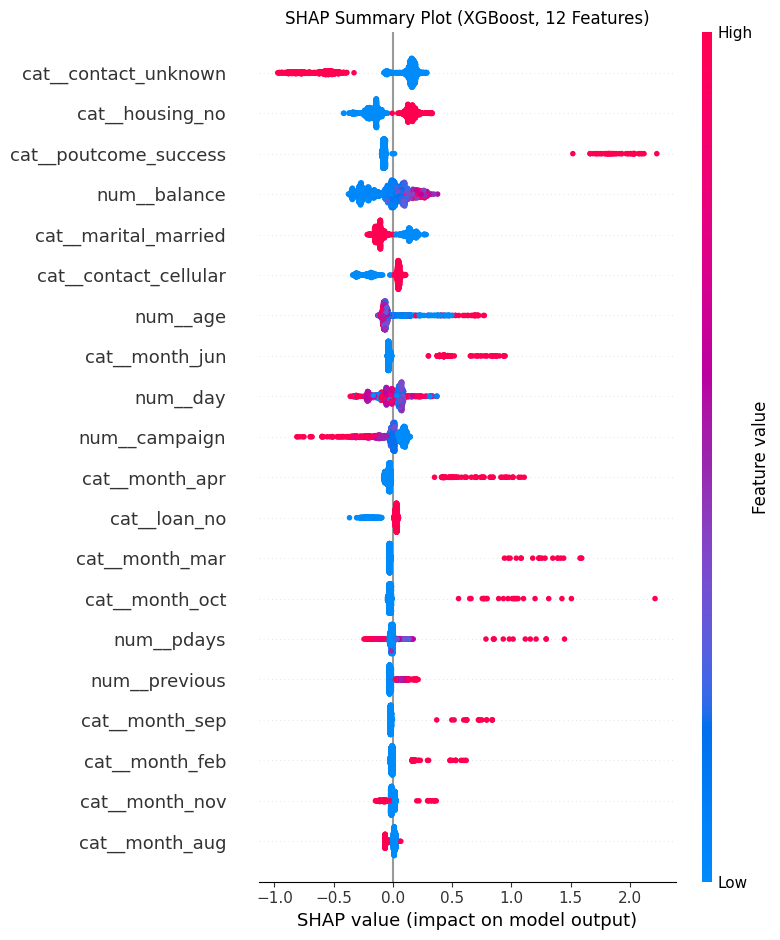


Top features by mean(|SHAP|):


,feature,mean_abs_shap
0,cat__contact_unknown,0.301229
1,cat__housing_no,0.166755
2,cat__poutcome_success,0.140627
3,num__balance,0.133401
4,cat__marital_married,0.127448
5,cat__contact_cellular,0.110488
6,num__age,0.090987
7,cat__month_jun,0.090783
8,num__day,0.085678
9,num__campaign,0.083833


In [54]:
# =========================================================
# Topic 11: Model Explainability (SHAP) - XGBoost (Pipeline)
# =========================================================
!pip -q install shap

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Get the best estimator (might be a Pipeline)
xgb_pipe = grid_xgb_v2.best_estimator_

# 2) Extract preprocess + model from pipeline
# (your step names are likely 'preprocess' and 'model'; if not, print(xgb_pipe.named_steps))
preprocess = xgb_pipe.named_steps["preprocess"]
xgb_model = xgb_pipe.named_steps["model"]

# 3) Transform test data into model input space
X_test_trans = preprocess.transform(X_test_v2)

# Optional: sample for speed
rng = np.random.RandomState(42)
n = X_test_trans.shape[0]
idx = rng.choice(n, size=min(1500, n), replace=False)
X_explain = X_test_trans[idx]

# 4) SHAP TreeExplainer (use the real model, NOT the pipeline)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_explain)

# 5) Feature names
feature_names = preprocess.get_feature_names_out()

# Convert sparse to dense for plotting if needed
X_dense = X_explain.toarray() if hasattr(X_explain, "toarray") else X_explain

# 6) Summary plot
shap.summary_plot(shap_values, X_dense, feature_names=feature_names, show=False)
plt.title("SHAP Summary Plot (XGBoost, 12 Features)")
plt.tight_layout()
plt.show()

# 7) Top 12 features by mean(|SHAP|)
mean_abs_shap = np.mean(np.abs(shap_values), axis=0)
top_idx = np.argsort(mean_abs_shap)[::-1][:12]

top_features = pd.DataFrame({
    "feature": np.array(feature_names)[top_idx],
    "mean_abs_shap": mean_abs_shap[top_idx]
}).reset_index(drop=True)

print("\nTop features by mean(|SHAP|):")
display(top_features)
